# E-Commerce Conversion Funnel Analysis

This project analyzes customer behavior throughout an e-commerce conversion funnel, from browsing to completed purchase. The analysis focuses on customer drop-off, conversion rates, funnel bottlenecks, and performance differences across key customer segments.

The objective is to identify opportunities for improving the customer journey and increasing overall conversion.

In [1]:
import pandas as pd
import numpy as np

## 1. Data Loading

This section loads the e-commerce funnel dataset into Python and performs an initial inspection of the available records and variables.

In [2]:
df = pd.read_csv("funnel_analysis_data.csv")

In [3]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


## 2. Data Understanding & Cleaning

This section examines the structure and quality of the dataset. It includes checking the dataset dimensions, data types, missing values, duplicate records, unique values, categorical variables, and timestamp formatting.

The goal is to ensure that the dataset is accurate and appropriately prepared for analysis.

In [5]:
df.shape


(21663, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           21663 non-null  object 
 1   Session_ID        21663 non-null  object 
 2   Event             21663 non-null  object 
 3   Timestamp         21663 non-null  object 
 4   Device            21663 non-null  object 
 5   Region            21663 non-null  object 
 6   Channel           21663 non-null  object 
 7   Product_Category  21663 non-null  object 
 8   Revenue           21663 non-null  float64
 9   Bounce_Flag       21663 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.7+ MB


In [7]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [8]:
df["Timestamp"].dtype

dtype('<M8[ns]')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           21663 non-null  object        
 1   Session_ID        21663 non-null  object        
 2   Event             21663 non-null  object        
 3   Timestamp         21663 non-null  datetime64[ns]
 4   Device            21663 non-null  object        
 5   Region            21663 non-null  object        
 6   Channel           21663 non-null  object        
 7   Product_Category  21663 non-null  object        
 8   Revenue           21663 non-null  float64       
 9   Bounce_Flag       21663 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.7+ MB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21564
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              1078
Bounce_Flag             2
dtype: int64

In [12]:
df["Event"].value_counts()

Event
Browse         10000
Add to Cart     7059
Checkout        3524
Purchase        1080
Name: count, dtype: int64

In [25]:
df["Device"].value_counts()

Device
Tablet     7237
Desktop    7235
Mobile     7191
Name: count, dtype: int64

In [14]:
df["Region"].value_counts()

Region
West     5462
North    5428
East     5391
South    5382
Name: count, dtype: int64

In [15]:
df["Channel"].value_counts()

Channel
Google Ads      5435
Email           5433
Social Media    5412
Organic         5383
Name: count, dtype: int64

In [16]:
df["Product_Category"].value_counts()

Product_Category
Electronics    4405
Fashion        4400
Sports         4348
Beauty         4280
Home           4230
Name: count, dtype: int64

In [17]:
df["Bounce_Flag"].value_counts()

Bounce_Flag
Yes    17343
No      4320
Name: count, dtype: int64

In [19]:
df["Timestamp"].min(),df["Timestamp"].max()

(Timestamp('2025-10-01 19:30:17'), Timestamp('2025-10-31 19:25:15'))

In [20]:
df["Timestamp"].describe()

count                            21663
mean     2025-10-16 19:56:22.920740608
min                2025-10-01 19:30:17
25%                2025-10-09 08:31:38
50%                2025-10-16 19:47:21
75%                2025-10-24 08:13:17
max                2025-10-31 19:25:15
Name: Timestamp, dtype: object

In [21]:
df["Revenue"].describe()

count    21663.000000
mean        54.304841
std        262.692471
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1998.510000
Name: Revenue, dtype: float64

In [22]:
df["Revenue"].value_counts().head(10)

Revenue
0.00       20583
1523.73        2
1724.64        2
933.69         2
1644.54        1
1754.15        1
751.13         1
1376.23        1
1537.99        1
284.23         1
Name: count, dtype: int64

## 3. Funnel Analysis

This section examines the progression of customers through the four stages of the e-commerce funnel: Browse, Add to Cart, Checkout, and Purchase.

Conversion rates and drop-off rates are calculated between each stage to identify where the greatest loss of customers occurs.

In [23]:
funnel_df = df.copy()

In [24]:
funnel_df

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.00,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.00,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.00,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.00,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.00,No
...,...,...,...,...,...,...,...,...,...,...
21658,USR09999,SES09999,Browse,2025-10-03 17:22:58,Desktop,South,Google Ads,Electronics,0.00,No
21659,USR09999,SES09999,Add to Cart,2025-10-03 17:26:58,Tablet,West,Social Media,Fashion,0.00,No
21660,USR09999,SES09999,Checkout,2025-10-03 17:29:58,Mobile,North,Email,Fashion,0.00,No
21661,USR09999,SES09999,Purchase,2025-10-03 17:34:58,Mobile,East,Email,Fashion,960.65,No


In [26]:
bounce_rate = funnel_df["Bounce_Flag"].value_counts(normalize=True) * 100
bounce_rate

Bounce_Flag
Yes    80.058164
No     19.941836
Name: proportion, dtype: float64

In [27]:
funnel_df.groupby("Event")["Session_ID"].nunique()

Event
Add to Cart     7059
Browse         10000
Checkout        3524
Purchase        1080
Name: Session_ID, dtype: int64

In [28]:
funnel_df.groupby("Session_ID")["Event"].count().value_counts().sort_index()

Event
1    2941
2    3535
3    2444
4    1080
Name: count, dtype: int64

In [29]:
funnel_df.groupby("Session_ID")["Event"].nunique().value_counts().sort_index()

Event
1    2941
2    3535
3    2444
4    1080
Name: count, dtype: int64

In [30]:
stage_counts = funnel_df.groupby("Event")["Session_ID"].nunique()

stage_counts

Event
Add to Cart     7059
Browse         10000
Checkout        3524
Purchase        1080
Name: Session_ID, dtype: int64

In [31]:
stage_order = ["Browse", "Add to Cart", "Checkout", "Purchase"]

stage_counts = stage_counts.reindex(stage_order)

stage_counts

Event
Browse         10000
Add to Cart     7059
Checkout        3524
Purchase        1080
Name: Session_ID, dtype: int64

In [36]:
overall_conversion = (
    stage_counts["Purchase"] / stage_counts["Browse"]
) * 100

overall_conversion


np.float64(10.8)

In [43]:
print("Overall Conversion rate =", overall_conversion,"%")

Overall Conversion rate = 10.8 %


In [44]:
browse_to_cart = (
    stage_counts["Add to Cart"] / stage_counts["Browse"]
) * 100

cart_to_checkout = (
    stage_counts["Checkout"] / stage_counts["Add to Cart"]
) * 100

checkout_to_purchase = (
    stage_counts["Purchase"] / stage_counts["Checkout"]
) * 100

browse_to_cart, cart_to_checkout, checkout_to_purchase

(np.float64(70.59),
 np.float64(49.922085281201305),
 np.float64(30.64699205448354))

In [49]:
print("Browse to cart conversion rate =", browse_to_cart,"%")

print("Cart to checkout conversion rate =", cart_to_checkout,"%")
      
print("Checkout to purchase conversion rate =", checkout_to_purchase,"%") 

Browse to cart conversion rate = 70.59 %
Cart to checkout conversion rate = 49.922085281201305 %
Checkout to purchase conversion rate = 30.64699205448354 %


In [78]:
browse_cart_dropoff = 100 - browse_to_cart
cart_checkout_dropoff = 100 - cart_to_checkout
checkout_purchase_dropoff = 100 - checkout_to_purchase

browse_cart_dropoff, cart_checkout_dropoff, checkout_purchase_dropoff

(np.float64(29.409999999999997),
 np.float64(50.077914718798695),
 np.float64(69.35300794551645))

In [80]:
print("Browse to cart drop-off rate =", browse_cart_dropoff,"%")

print("Cart to checkout drop-off rate =", cart_checkout_dropoff,"%")
      
print("Checkout to purchase drop-off rate =", checkout_purchase_dropoff,"%") 

Browse to cart drop-off rate = 29.409999999999997 %
Cart to checkout drop-off rate = 50.077914718798695 %
Checkout to purchase drop-off rate = 69.35300794551645 %


In [52]:
funnel_analysis = pd.DataFrame({
    "Stage": [
        "Browse",
        "Add to Cart",
        "Checkout",
        "Purchase"
    ],
    "Sessions": [
        stage_counts["Browse"],
        stage_counts["Add to Cart"],
        stage_counts["Checkout"],
        stage_counts["Purchase"]
    ]
})

funnel_analysis

,Stage,Sessions
0,Browse,10000
1,Add to Cart,7059
2,Checkout,3524
3,Purchase,1080


In [55]:
funnel_analysis["Overall Conversion %"] = (
    funnel_analysis["Sessions"] /
    funnel_analysis["Sessions"].iloc[0]
) * 100

In [56]:
funnel_analysis

,Stage,Sessions,Overall Conversion %
0,Browse,10000,100.00
1,Add to Cart,7059,70.59
2,Checkout,3524,35.24
3,Purchase,1080,10.80


In [64]:
funnel_analysis["Stage Conversion %"] = [
    100,
    browse_to_cart,
    cart_to_checkout,
    checkout_to_purchase
]

In [75]:
funnel_analysis["Stage Drop-off %"] = [
    0,
    browse_cart_dropoff,
    cart_checkout_dropoff,
    checkout_purchase_dropoff
]

In [76]:
funnel_analysis.round(2)

,Stage,Sessions,Overall Conversion %,Stage Drop-off %,Stage Conversion %
0,Browse,10000,100.00,0.00,100.00
1,Add to Cart,7059,70.59,29.41,70.59
2,Checkout,3524,35.24,50.08,49.92
3,Purchase,1080,10.80,69.35,30.65


### Preliminary Funnel Finding
The funnel analysis shows a **progressive decline in customer participation from Browse to Purchase**. While **70.59%** of browsing sessions progressed to Add to Cart, only **49.92%** of those sessions proceeded to Checkout, and just **30.65%** of checkout sessions resulted in a purchase. The largest drop-off occurs between Checkout and Purchase, where **69.35%** of sessions are lost, indicating that the **checkout-to-purchase stage is the primary bottleneck requiring further investigation**.

## 4. Segment Analysis

This section evaluates funnel performance across different customer segments, including device type, acquisition channel, region, and product category.

The analysis compares stage-to-stage and overall conversion rates to identify segments with particularly strong or weak performance.

In [83]:
device_funnel = (
    funnel_df
    .groupby(["Device", "Event"])["Session_ID"]
    .nunique()
    .unstack(fill_value=0)
)

device_funnel

Event,Add to Cart,Browse,Checkout,Purchase
Device,,,,
Desktop,2399,3331,1177,328
Mobile,2329,3345,1148,369
Tablet,2331,3324,1199,383


In [68]:
device_conversion = pd.DataFrame(index=device_funnel.index)

device_conversion["Browse → Cart %"] = (
    device_funnel["Add to Cart"] /
    device_funnel["Browse"]
) * 100

device_conversion["Cart → Checkout %"] = (
    device_funnel["Checkout"] /
    device_funnel["Add to Cart"]
) * 100

device_conversion["Checkout → Purchase %"] = (
    device_funnel["Purchase"] /
    device_funnel["Checkout"]
) * 100

device_conversion["Overall Conversion %"] = (
    device_funnel["Purchase"] /
    device_funnel["Browse"]
) * 100

device_conversion.round(2)

,Browse → Cart %,Cart → Checkout %,Checkout → Purchase %,Overall Conversion %
Device,,,,
Desktop,72.02,49.06,27.87,9.85
Mobile,69.63,49.29,32.14,11.03
Tablet,70.13,51.44,31.94,11.52


In [81]:
channel_funnel = (
    funnel_df
    .groupby(["Channel", "Event"])["Session_ID"]
    .nunique()
    .unstack(fill_value=0)
)

channel_funnel

Event,Add to Cart,Browse,Checkout,Purchase
Channel,,,,
Email,1788,2489,877,279
Google Ads,1708,2560,888,279
Organic,1754,2511,861,257
Social Media,1809,2440,898,265


In [82]:
channel_conversion = pd.DataFrame(index=channel_funnel.index)

channel_conversion["Browse → Cart %"] = (
    channel_funnel["Add to Cart"] /
    channel_funnel["Browse"]
) * 100

channel_conversion["Cart → Checkout %"] = (
    channel_funnel["Checkout"] /
    channel_funnel["Add to Cart"]
) * 100

channel_conversion["Checkout → Purchase %"] = (
    channel_funnel["Purchase"] /
    channel_funnel["Checkout"]
) * 100

channel_conversion["Overall Conversion %"] = (
    channel_funnel["Purchase"] /
    channel_funnel["Browse"]
) * 100

channel_conversion.round(2)

,Browse → Cart %,Cart → Checkout %,Checkout → Purchase %,Overall Conversion %
Channel,,,,
Email,71.84,49.05,31.81,11.21
Google Ads,66.72,51.99,31.42,10.90
Organic,69.85,49.09,29.85,10.23
Social Media,74.14,49.64,29.51,10.86


In [84]:
region_funnel = (
    funnel_df
    .groupby(["Region", "Event"])["Session_ID"]
    .nunique()
    .unstack(fill_value=0)
)

region_funnel

Event,Add to Cart,Browse,Checkout,Purchase
Region,,,,
East,1728,2514,866,283
North,1737,2504,916,271
South,1761,2506,848,267
West,1833,2476,894,259


In [85]:
region_conversion = pd.DataFrame(index=region_funnel.index)

region_conversion["Browse → Cart %"] = (
    region_funnel["Add to Cart"] /
    region_funnel["Browse"]
) * 100

region_conversion["Cart → Checkout %"] = (
    region_funnel["Checkout"] /
    region_funnel["Add to Cart"]
) * 100

region_conversion["Checkout → Purchase %"] = (
    region_funnel["Purchase"] /
    region_funnel["Checkout"]
) * 100

region_conversion["Overall Conversion %"] = (
    region_funnel["Purchase"] /
    region_funnel["Browse"]
) * 100

region_conversion.round(2)

,Browse → Cart %,Cart → Checkout %,Checkout → Purchase %,Overall Conversion %
Region,,,,
East,68.74,50.12,32.68,11.26
North,69.37,52.73,29.59,10.82
South,70.27,48.15,31.49,10.65
West,74.03,48.77,28.97,10.46


In [86]:
category_funnel = (
    funnel_df
    .groupby(["Product_Category", "Event"])["Session_ID"]
    .nunique()
    .unstack(fill_value=0)
)

category_funnel

Event,Add to Cart,Browse,Checkout,Purchase
Product_Category,,,,
Beauty,1402,1978,699,201
Electronics,1444,2046,686,229
Fashion,1435,2035,707,223
Home,1341,1941,736,212
Sports,1437,2000,696,215


In [87]:
category_conversion = pd.DataFrame(index=category_funnel.index)

category_conversion["Browse → Cart %"] = (
    category_funnel["Add to Cart"] /
    category_funnel["Browse"]
) * 100

category_conversion["Cart → Checkout %"] = (
    category_funnel["Checkout"] /
    category_funnel["Add to Cart"]
) * 100

category_conversion["Checkout → Purchase %"] = (
    category_funnel["Purchase"] /
    category_funnel["Checkout"]
) * 100

category_conversion["Overall Conversion %"] = (
    category_funnel["Purchase"] /
    category_funnel["Browse"]
) * 100

category_conversion.round(2)

,Browse → Cart %,Cart → Checkout %,Checkout → Purchase %,Overall Conversion %
Product_Category,,,,
Beauty,70.88,49.86,28.76,10.16
Electronics,70.58,47.51,33.38,11.19
Fashion,70.52,49.27,31.54,10.96
Home,69.09,54.88,28.80,10.92
Sports,71.85,48.43,30.89,10.75


## 5. Bounce Rate Analysis

This section examines customer bounce behavior at the session level. Bounce rates are analyzed overall and across different customer segments to determine whether certain groups are more likely to leave without progressing through the funnel.

In [90]:
session_bounce = (
    funnel_df
    .groupby("Session_ID")["Bounce_Flag"]
    .first()
)

session_bounce.value_counts()

Bounce_Flag
Yes    8920
No     1080
Name: count, dtype: int64

In [91]:
session_bounce.value_counts(normalize=True).mul(100).round(2)

Bounce_Flag
Yes    89.2
No     10.8
Name: proportion, dtype: float64

In [92]:
device_bounce = (
    funnel_df
    .groupby("Device")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

device_bounce

Device
Desktop    80.44
Mobile     79.75
Tablet     79.98
Name: Bounce_Flag, dtype: float64

In [93]:
channel_bounce = (
    funnel_df
    .groupby("Channel")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

channel_bounce

Channel
Email           80.40
Google Ads      80.00
Organic         79.81
Social Media    80.03
Name: Bounce_Flag, dtype: float64

In [94]:
region_bounce = (
    funnel_df
    .groupby("Region")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

region_bounce

Region
East     78.87
North    80.71
South    79.69
West     80.94
Name: Bounce_Flag, dtype: float64

In [95]:
category_bounce = (
    funnel_df
    .groupby("Product_Category")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

category_bounce

Product_Category
Beauty         80.21
Electronics    80.36
Fashion        80.34
Home           79.69
Sports         79.67
Name: Bounce_Flag, dtype: float64

In [96]:
session_df = funnel_df.groupby("Session_ID").first().reset_index()


In [97]:
session_df 

,Session_ID,User_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,SES00001,USR00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,SES00002,USR00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
2,SES00003,USR00003,Browse,2025-10-12 02:19:00,Desktop,East,Google Ads,Beauty,0.0,No
3,SES00004,USR00004,Browse,2025-10-05 17:55:48,Tablet,West,Social Media,Home,0.0,Yes
4,SES00005,USR00005,Browse,2025-10-19 12:35:49,Tablet,West,Google Ads,Electronics,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...
9995,SES09996,USR09996,Browse,2025-10-24 13:47:03,Desktop,South,Organic,Sports,0.0,No
9996,SES09997,USR09997,Browse,2025-10-28 02:53:54,Mobile,South,Google Ads,Home,0.0,Yes
9997,SES09998,USR09998,Browse,2025-10-09 12:04:15,Tablet,East,Social Media,Beauty,0.0,Yes
9998,SES09999,USR09999,Browse,2025-10-03 17:22:58,Desktop,South,Google Ads,Electronics,0.0,No


In [101]:
device_bounce = (
    session_df
    .groupby("Device")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

device_bounce



Device
Desktop    88.83
Mobile     89.15
Tablet     89.62
Name: Bounce_Flag, dtype: float64

In [102]:

channel_bounce = (
    session_df
    .groupby("Channel")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

channel_bounce

Channel
Email           89.80
Google Ads      88.98
Organic         88.81
Social Media    89.22
Name: Bounce_Flag, dtype: float64

In [103]:
region_bounce = (
    session_df
    .groupby("Region")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

region_bounce

Region
East     88.86
North    89.58
South    88.75
West     89.62
Name: Bounce_Flag, dtype: float64

In [104]:
category_bounce = (
    session_df
    .groupby("Product_Category")["Bounce_Flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)
category_bounce 

Product_Category
Beauty         88.57
Electronics    89.83
Fashion        89.19
Home           89.13
Sports         89.25
Name: Bounce_Flag, dtype: float64

## 6. Revenue Analysis

This section examines the financial performance of the e-commerce funnel by analyzing revenue generated from completed purchases.

The analysis focuses on total revenue, average purchase value, and revenue distribution to determine which customer segments and product categories contribute most to overall revenue.

By combining revenue performance with the funnel conversion results, we can assess whether segments with higher conversion rates also generate greater financial value.

In [105]:
total_revenue = funnel_df["Revenue"].sum()
average_revenue = funnel_df.loc[
    funnel_df["Event"] == "Purchase", "Revenue"
].mean()
median_revenue = funnel_df.loc[
    funnel_df["Event"] == "Purchase", "Revenue"
].median()

total_revenue, average_revenue, median_revenue

(np.float64(1176405.78), np.float64(1089.2646111111114), 1099.83)

In [108]:
print("Total Revenue =", total_revenue)

print("Average Revenue =", average_revenue.round(2))

print("Median Revenue =", median_revenue)

Total Revenue = 1176405.78
Average Revenue = 1089.26
Median Revenue = 1099.83


In [109]:
funnel_df[funnel_df["Event"] == "Purchase"]["Revenue"].describe()

count    1080.000000
mean     1089.264611
std       506.952790
min       201.260000
25%       661.672500
50%      1099.830000
75%      1519.822500
max      1998.510000
Name: Revenue, dtype: float64

In [110]:
category_revenue = (
    funnel_df[funnel_df["Event"] == "Purchase"]
    .groupby("Product_Category")["Revenue"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

category_revenue

,sum,mean,count
Product_Category,,,
Electronics,256035.81,1118.060306,229
Fashion,244761.32,1097.584395,223
Home,230160.90,1085.664623,212
Sports,227888.10,1059.944651,215
Beauty,217559.65,1082.386318,201


In [111]:
channel_revenue = (
    funnel_df[funnel_df["Event"] == "Purchase"]
    .groupby("Channel")["Revenue"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

channel_revenue

,sum,mean,count
Channel,,,
Email,308902.10,1107.175986,279
Google Ads,305053.00,1093.379928,279
Social Media,292971.23,1105.551811,265
Organic,269479.45,1048.558171,257


In [112]:
device_revenue = (
    funnel_df[funnel_df["Event"] == "Purchase"]
    .groupby("Device")["Revenue"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

device_revenue

,sum,mean,count
Device,,,
Tablet,415491.96,1084.835405,383
Mobile,403652.25,1093.908537,369
Desktop,357261.57,1089.212104,328


In [113]:
region_revenue = (
    funnel_df[funnel_df["Event"] == "Purchase"]
    .groupby("Region")["Revenue"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

region_revenue

,sum,mean,count
Region,,,
East,312151.95,1103.010424,283
North,304289.92,1122.841033,271
South,283255.96,1060.883745,267
West,276707.95,1068.370463,259


## 7. Revenue Contribution Analysis

This section examines the proportion of total revenue contributed by each device, acquisition channel, region, and product category.

Revenue contribution provides additional context to total revenue by showing the relative financial importance of each segment within the overall business.

In [114]:
category_revenue["Revenue Contribution %"] = (
    category_revenue["sum"] / total_revenue
) * 100

category_revenue["Revenue Contribution %"] = (
    category_revenue["Revenue Contribution %"].round(2)
)

category_revenue

,sum,mean,count,Revenue Contribution %
Product_Category,,,,
Electronics,256035.81,1118.060306,229,21.76
Fashion,244761.32,1097.584395,223,20.81
Home,230160.90,1085.664623,212,19.56
Sports,227888.10,1059.944651,215,19.37
Beauty,217559.65,1082.386318,201,18.49


### Product Category Revenue Contribution

**Electronics contributes the largest share of total revenue at 21.76%**, followed by Fashion at 20.81%. Beauty contributes the smallest share at 18.49%. Overall, revenue is relatively evenly distributed across product categories, with only a 3.27 percentage-point difference between the highest and lowest contributors.

In [115]:
channel_revenue["Revenue Contribution %"] = (
    channel_revenue["sum"] / total_revenue
) * 100

channel_revenue["Revenue Contribution %"] = (
    channel_revenue["Revenue Contribution %"].round(2)
)

channel_revenue

,sum,mean,count,Revenue Contribution %
Channel,,,,
Email,308902.10,1107.175986,279,26.26
Google Ads,305053.00,1093.379928,279,25.93
Social Media,292971.23,1105.551811,265,24.90
Organic,269479.45,1048.558171,257,22.91


### Channel Revenue Contribution

**Email contributes the largest share of total revenue at 26.26%**, followed closely by Google Ads at 25.93%. Although Email and Google Ads generated the same number of purchases, Email produced slightly higher revenue due to its higher average purchase value. Overall, revenue contribution is relatively balanced across the four acquisition channels.

In [116]:
device_revenue["Revenue Contribution %"] = (
    device_revenue["sum"] / total_revenue
) * 100

device_revenue["Revenue Contribution %"] = (
    device_revenue["Revenue Contribution %"].round(2)
)

device_revenue

,sum,mean,count,Revenue Contribution %
Device,,,,
Tablet,415491.96,1084.835405,383,35.32
Mobile,403652.25,1093.908537,369,34.31
Desktop,357261.57,1089.212104,328,30.37


### Device Revenue Contribution

**Tablet users contribute the largest share of total revenue at 35.32%**, followed by Mobile users at 34.31%. This aligns with Tablet having the highest overall funnel conversion rate. Desktop contributes the smallest share of revenue at 30.37%, consistent with its lower overall conversion rate. Although Mobile has the highest average purchase value, Tablet generates more total revenue due to its higher number of completed purchases.

In [117]:
region_revenue["Revenue Contribution %"] = (
    region_revenue["sum"] / total_revenue
) * 100

region_revenue["Revenue Contribution %"] = (
    region_revenue["Revenue Contribution %"].round(2)
)

region_revenue

,sum,mean,count,Revenue Contribution %
Region,,,,
East,312151.95,1103.010424,283,26.53
North,304289.92,1122.841033,271,25.87
South,283255.96,1060.883745,267,24.08
West,276707.95,1068.370463,259,23.52


### Region Revenue Contribution

**East contributes the largest share of total revenue at 26.53%**, supported by the highest number of completed purchases and the highest overall funnel conversion rate. North has the highest average purchase value at 1,122.84 despite having fewer purchases than East. West contributes the smallest share of revenue at 23.52%. Overall, revenue contribution is relatively balanced across regions.

## 8. Data Visualization

This section presents the key findings from the analysis using visualizations. Charts are used to make patterns in customer conversion, drop-off, revenue performance, and segment-level differences easier to identify and interpret.

The visualizations focus on the most relevant findings rather than displaying every calculated metric, allowing the key business insights to be communicated clearly and effectively.

### 8.1 Overall Conversion Funnel

The conversion funnel visualizes the progression of sessions through the four stages of the customer journey: Browse, Add to Cart, Checkout, and Purchase. It highlights the volume of sessions retained at each stage and helps identify the point at which the greatest customer drop-off occurs.

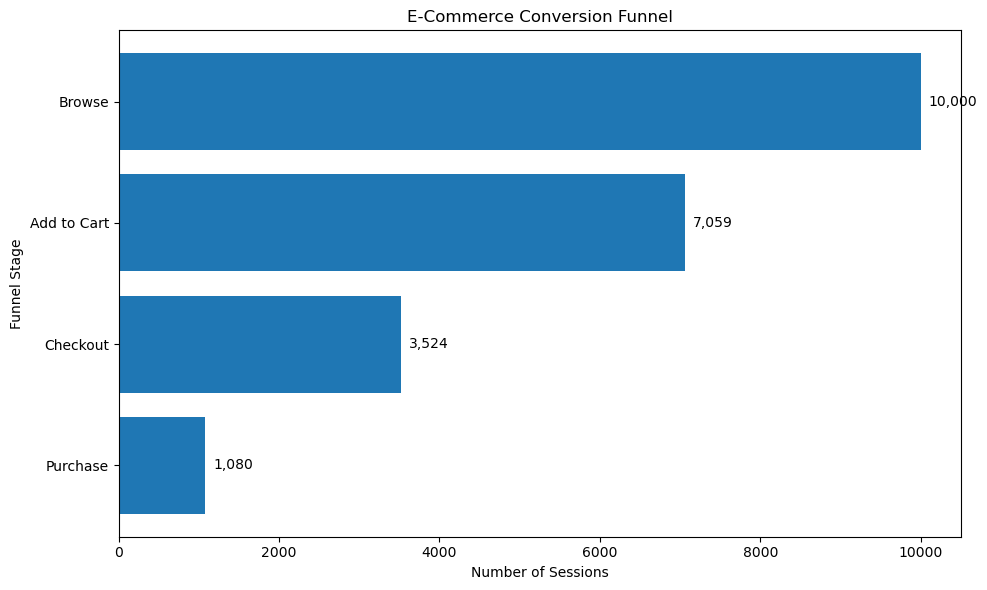

In [123]:
import matplotlib.pyplot as plt

stages = funnel_analysis["Stage"]
sessions = funnel_analysis["Sessions"]
overall_conversion = funnel_analysis["Overall Conversion %"]

plt.figure(figsize=(10, 6))

plt.barh(stages, sessions)

plt.xlabel("Number of Sessions")
plt.ylabel("Funnel Stage")
plt.title("E-Commerce Conversion Funnel")

plt.gca().invert_yaxis()

for i, value in enumerate(sessions):
    plt.text(value + 100, i, f"{value:,}", va="center")

plt.tight_layout()
plt.show()

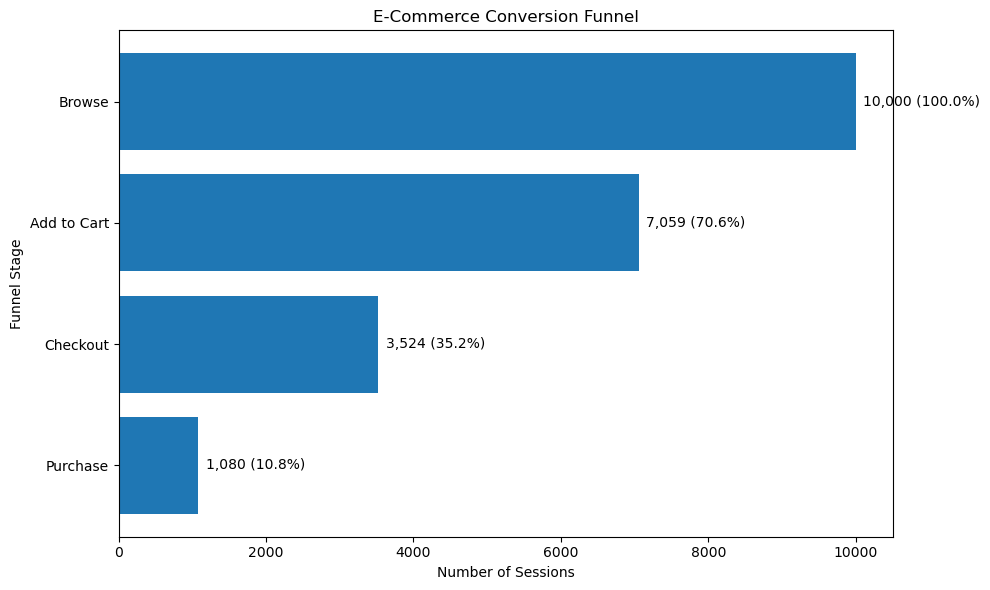

In [121]:
overall_conversion = funnel_analysis["Overall Conversion %"]

plt.figure(figsize=(10, 6))

plt.barh(stages, sessions)

plt.xlabel("Number of Sessions")
plt.ylabel("Funnel Stage")
plt.title("E-Commerce Conversion Funnel")

plt.gca().invert_yaxis()

for i, (sessions_value, conversion) in enumerate(
    zip(sessions, overall_conversion)
):
    plt.text(
        sessions_value + 100,
        i,
        f"{sessions_value:,} ({conversion:.1f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

### Funnel Visualization — Interpretation

The e-commerce funnel **begins with 10,000** browsing sessions and **ends with 1,080** completed purchases, resulting in an **overall conversion rate of 10.8%**.

The largest drop-off occurs between Checkout and Purchase, where **69.35% of sessions fail to progress to a completed purchase**. This identifies the Checkout-to-Purchase stage as the primary bottleneck in the customer journey and an important area for further investigation.

### 8.2 Overall Conversion Rate by Device

This visualization compares the overall conversion rate across desktop, mobile, and tablet users. It highlights differences in customer purchasing behavior by device and identifies the device segment with the strongest and weakest conversion performance.

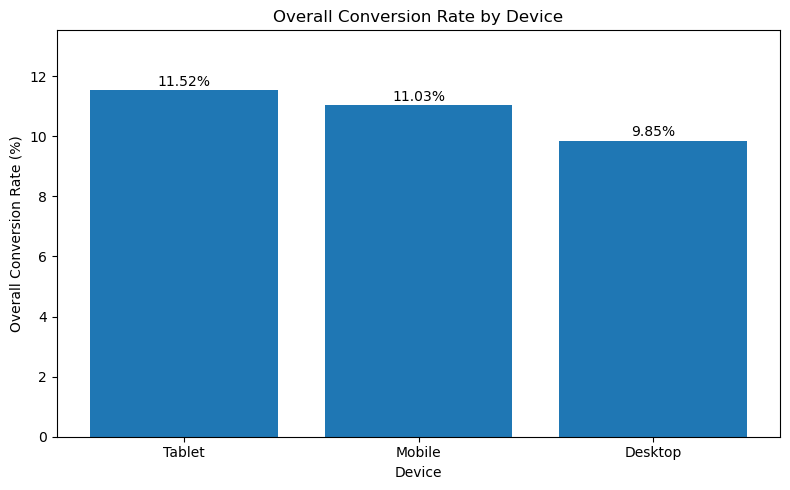

In [124]:
device_conversion_sorted = (
    device_conversion["Overall Conversion %"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    device_conversion_sorted.index,
    device_conversion_sorted.values
)

plt.xlabel("Device")
plt.ylabel("Overall Conversion Rate (%)")
plt.title("Overall Conversion Rate by Device")

for i, value in enumerate(device_conversion_sorted.values):
    plt.text(i, value + 0.15, f"{value:.2f}%", ha="center")

plt.ylim(0, max(device_conversion_sorted.values) + 2)

plt.tight_layout()
plt.show()

### Interpretation

**Tablet users have the highest overall conversion rate at 11.52%**, followed by mobile users at 11.03%. Desktop users have the lowest conversion rate at 9.85%.

The results suggest that desktop users are less likely to complete a purchase compared with mobile and tablet users. However, the difference is relatively modest, so further investigation would be required to determine the factors contributing to the lower desktop conversion rate.

### 8.3 Overall Conversion Rate by Channel

This visualization compares the overall conversion rate across the different customer acquisition channels. It helps identify which channels are most effective at converting browsing sessions into completed purchases.

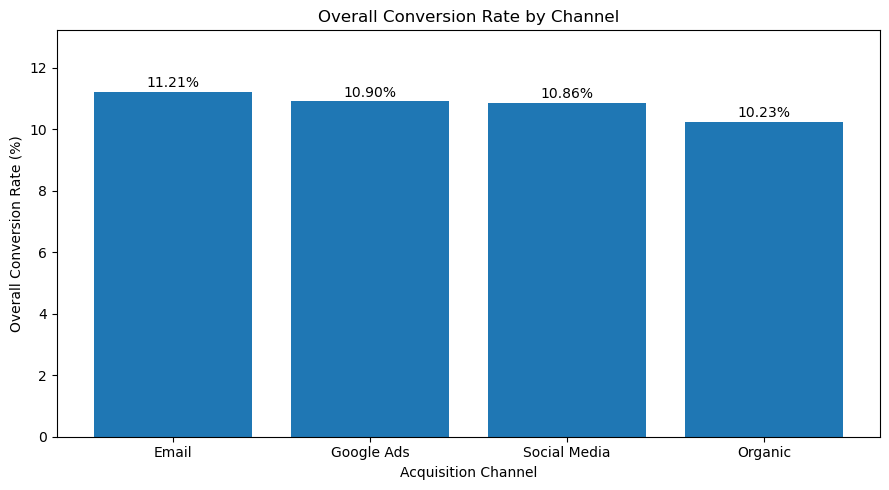

In [125]:
channel_conversion_sorted = (
    channel_conversion["Overall Conversion %"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    channel_conversion_sorted.index,
    channel_conversion_sorted.values
)

plt.xlabel("Acquisition Channel")
plt.ylabel("Overall Conversion Rate (%)")
plt.title("Overall Conversion Rate by Channel")

for i, value in enumerate(channel_conversion_sorted.values):
    plt.text(i, value + 0.15, f"{value:.2f}%", ha="center")

plt.ylim(0, max(channel_conversion_sorted.values) + 2)

plt.tight_layout()
plt.show()

### Interpretation

**Email has the highest overall conversion rate at 11.21%**, followed by Google Ads at 10.90% and Social Media at 10.86%. Organic has the lowest overall conversion rate at 10.23%.

Although Email performs best, the differences between channels are relatively small. This suggests that acquisition channel alone does not create a large difference in overall conversion performance. However, the variation at individual funnel stages indicates that different channels may influence customer behavior differently throughout the journey.

### 8.4 Total Revenue by Product Category

This visualization compares the total revenue generated by each product category. It highlights the categories that contribute the most and least to overall revenue and provides a financial perspective on product-level performance.

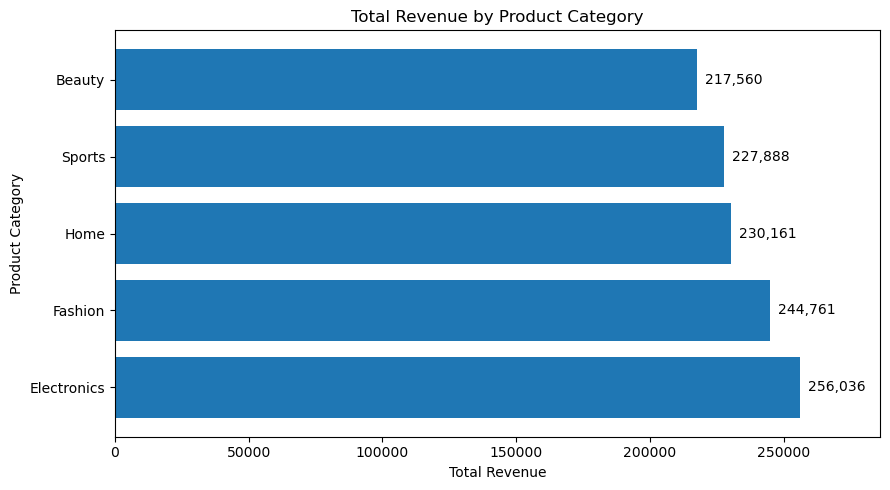

In [127]:
category_revenue_sorted = (
    category_revenue["sum"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.barh(
    category_revenue_sorted.index,
    category_revenue_sorted.values
)

plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.title("Total Revenue by Product Category")

for i, value in enumerate(category_revenue_sorted.values):
    plt.text(value + 3000, i, f"{value:,.0f}", va="center")

plt.xlim(0, max(category_revenue_sorted.values) + 30000)

plt.tight_layout()
plt.show()

### Interpretation

**Electronics generates the highest total revenue at 256,035.81, contributing 21.76% of total revenue**. Fashion follows with 244,761.32, while Beauty generates the lowest revenue at 217,559.65.

Overall, revenue is relatively evenly distributed across the five product categories, with Electronics and Beauty separated by approximately 3.27 percentage points in revenue contribution.

### 8.5 Total Revenue by Acquisition Channel

This visualization compares the total revenue generated by each acquisition channel. It helps identify which channels contribute the greatest financial value and provides context for the differences observed in channel-level conversion performance.

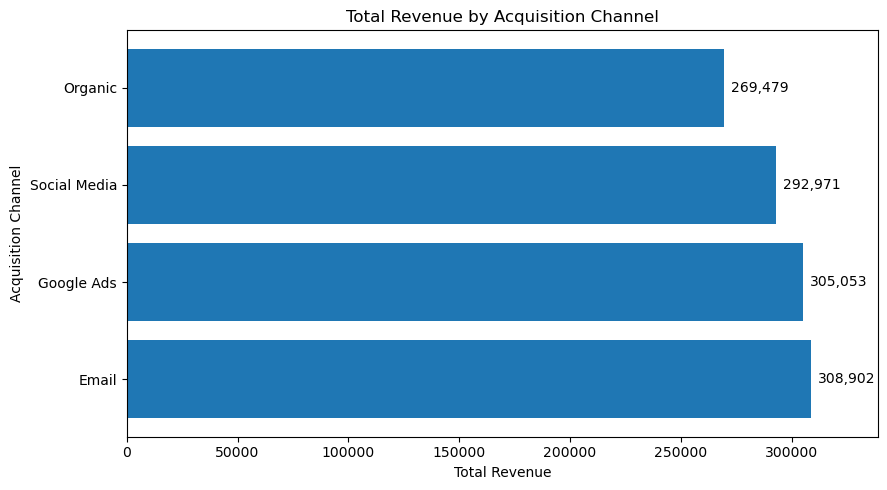

In [128]:
channel_revenue_sorted = (
    channel_revenue["sum"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.barh(
    channel_revenue_sorted.index,
    channel_revenue_sorted.values
)

plt.xlabel("Total Revenue")
plt.ylabel("Acquisition Channel")
plt.title("Total Revenue by Acquisition Channel")

for i, value in enumerate(channel_revenue_sorted.values):
    plt.text(value + 3000, i, f"{value:,.0f}", va="center")

plt.xlim(0, max(channel_revenue_sorted.values) + 30000)

plt.tight_layout()
plt.show()

### Interpretation

**Email generates the highest total revenue at 308,902.10, contributing 26.26% of total revenue**. Google Ads follows closely at 305,053.00, while Organic generates the lowest revenue at 269,479.45.

The relatively small difference between the highest and lowest revenue contributions indicates that revenue is fairly evenly distributed across the acquisition channels. Email's leading position is consistent with its highest overall conversion rate of 11.21%.

### 8.6 Total Revenue by Device

This visualization compares the total revenue generated by customers using different device types. It highlights the financial contribution of each device segment and allows the revenue results to be compared with the device-level conversion performance.

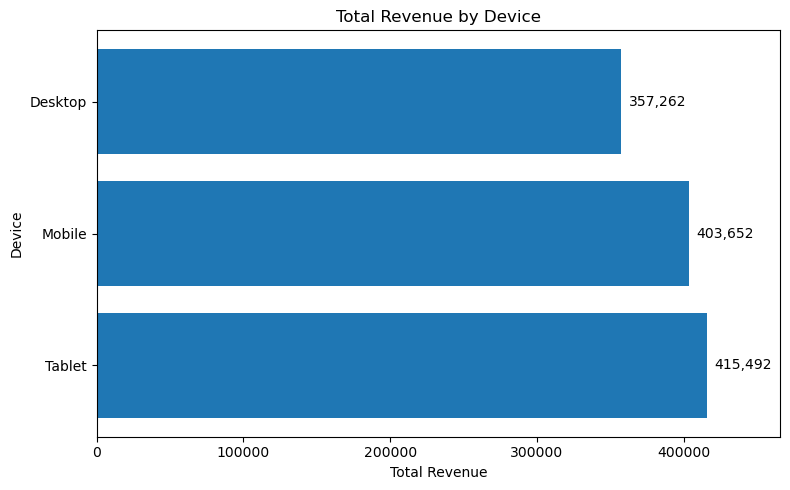

In [129]:
device_revenue_sorted = (
    device_revenue["sum"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    device_revenue_sorted.index,
    device_revenue_sorted.values
)

plt.xlabel("Total Revenue")
plt.ylabel("Device")
plt.title("Total Revenue by Device")

for i, value in enumerate(device_revenue_sorted.values):
    plt.text(value + 5000, i, f"{value:,.0f}", va="center")

plt.xlim(0, max(device_revenue_sorted.values) + 50000)

plt.tight_layout()
plt.show()

### Interpretation

**Tablet users generate the highest total revenue at 415,491.96, contributing 35.32% of total revenue**. Mobile users follow with 403,652.25, while Desktop users generate the lowest revenue at 357,261.57.

The results are consistent with the device-level funnel analysis, where Tablet users had the highest overall conversion rate of 11.52%, while Desktop users had the lowest at 9.85%. Although Mobile has the highest average purchase value, Tablet generates more total revenue because it has a greater number of completed purchases.

### 8.7 Total Revenue by Region

This visualization compares the total revenue generated across the four regions. It highlights differences in regional financial performance and allows revenue contribution to be considered alongside regional funnel conversion and purchase volume.

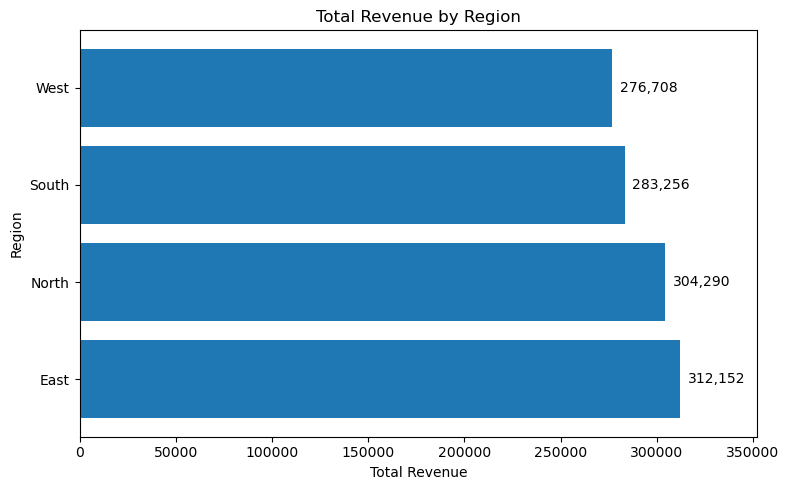

In [130]:
region_revenue_sorted = (
    region_revenue["sum"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    region_revenue_sorted.index,
    region_revenue_sorted.values
)

plt.xlabel("Total Revenue")
plt.ylabel("Region")
plt.title("Total Revenue by Region")

for i, value in enumerate(region_revenue_sorted.values):
    plt.text(value + 4000, i, f"{value:,.0f}", va="center")

plt.xlim(0, max(region_revenue_sorted.values) + 40000)

plt.tight_layout()
plt.show()

### Interpretation

**East generates the highest total revenue at 312,151.95, contributing 26.53% of total revenue**. North follows with 304,289.92, while West generates the lowest revenue at 276,707.95, contributing 23.52%.

East's leading revenue position is consistent with its highest overall funnel conversion rate of 11.26% and its highest number of completed purchases. North is notable for having the highest average purchase value at 1,122.84 despite generating fewer purchases than East.

Overall, regional revenue is relatively evenly distributed, with only a 3.01 percentage-point difference in revenue contribution between East and West.

### 8.7 Total Revenue by Region

This visualization compares the total revenue generated across the four regions. It highlights differences in regional financial performance and allows revenue contribution to be considered alongside regional funnel conversion and purchase volume.

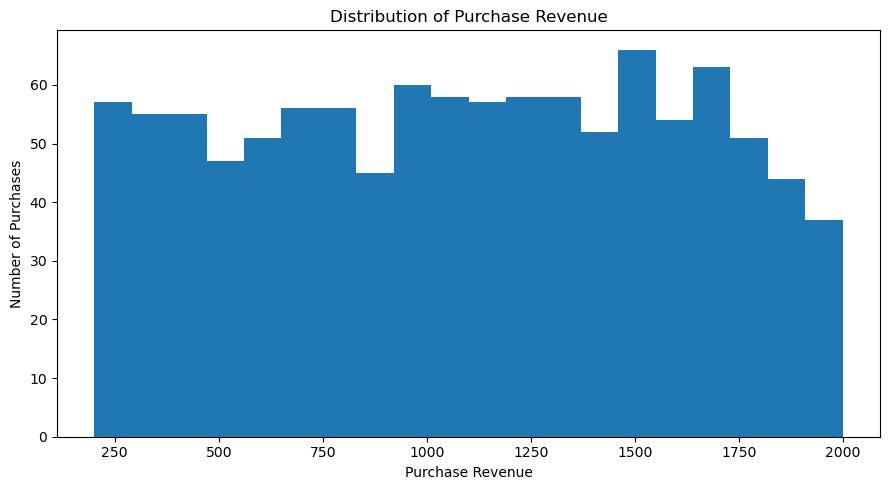

In [131]:
purchase_revenue = funnel_df.loc[
    funnel_df["Event"] == "Purchase",
    "Revenue"
]

plt.figure(figsize=(9, 5))

plt.hist(
    purchase_revenue,
    bins=20
)

plt.xlabel("Purchase Revenue")
plt.ylabel("Number of Purchases")
plt.title("Distribution of Purchase Revenue")

plt.tight_layout()
plt.show()

### Interpretation

**Purchase revenue is fairly evenly distributed across the range of approximately 200 to 2,000**, with no pronounced concentration around a single value range. The distribution shows some variation across the revenue intervals, with slightly fewer purchases toward the upper end of the range.

The mean purchase value of 1,089.26 is close to the median of 1,099.83, suggesting that the distribution does not exhibit strong overall skewness. Purchase values therefore show considerable variation while remaining broadly distributed across the observed range.

## 9. Key Findings & Business Insights

The analysis of the e-commerce conversion funnel revealed several important patterns in customer progression, segment performance, and revenue generation.

### 1. Checkout-to-Purchase is the Primary Funnel Bottleneck

The funnel begins with 10,000 browsing sessions and ends with 1,080 completed purchases, resulting in an overall conversion rate of 10.80%.

The largest drop-off occurs between Checkout and Purchase, where the conversion rate is only 30.65% and the drop-off rate is 69.35%. This indicates that the Checkout-to-Purchase stage represents the primary bottleneck in the customer journey and should be prioritized for further investigation.

### 2. Tablet Users Demonstrate the Strongest Overall Performance

Tablet users have the highest overall conversion rate at 11.52%, followed by Mobile at 11.03% and Desktop at 9.85%.

Tablet users also generate the highest total revenue at 415,491.96, contributing 35.32% of total revenue. This is supported by their higher number of completed purchases.

Desktop users show the weakest overall conversion and generate the lowest revenue among the three device groups, suggesting that desktop customer behavior warrants further investigation.

### 3. Email is the Strongest Acquisition Channel

Email has the highest overall conversion rate at 11.21% and generates the highest total revenue at 308,902.10, representing 26.26% of total revenue.

Google Ads follows closely with an overall conversion rate of 10.90% and revenue of 305,053.00. Although Email and Google Ads generated the same number of purchases, Email generated slightly more revenue because of its higher average purchase value.

### 4. Electronics is the Strongest Product Category

Electronics records the highest Checkout-to-Purchase conversion rate at 33.38% and generates the highest total revenue at 256,035.81, contributing 21.76% of total revenue.

However, Electronics has the lowest Cart-to-Checkout conversion rate at 47.51%, indicating that while customers who reach checkout are relatively likely to purchase, a significant proportion of customers leave before reaching checkout.

Beauty has the lowest overall conversion rate at 10.16% and the lowest total revenue at 217,559.65, making it a category that may warrant further investigation.

### 5. East Leads Regional Performance

East has the highest overall conversion rate at 11.26%, the highest number of completed purchases at 283, and the highest total revenue at 312,151.95, contributing 26.53% of total revenue.

North is notable for having the highest average purchase value at 1,122.84 despite having fewer purchases than East. This suggests that North customers generate relatively high-value transactions.

### 6. Revenue is Relatively Balanced Across Segments

Revenue is distributed relatively evenly across product categories, acquisition channels, devices, and regions.

For example, product category revenue contribution ranges from 18.49% for Beauty to 21.76% for Electronics, while regional contribution ranges from 23.52% for West to 26.53% for East.

This indicates that overall business performance is not dependent on a single category, channel, device, or region.

### 7. Bounce Rate is High but Shows Little Segment Variation

The dataset records an overall session-level bounce rate of 89.20%. However, bounce rates vary only slightly across the analyzed segments.

Device bounce rates range from 88.83% to 89.62%, while product category bounce rates range from 88.57% to 89.83%.

Therefore, bounce rate does not appear to be a major differentiating factor between the customer segments.

Because the Bounce_Flag is closely aligned with the number of non-purchasing sessions in this dataset, the 89.20% figure should be interpreted specifically as the proportion of sessions classified as bounced according to the dataset's Bounce_Flag variable, rather than automatically being interpreted as a conventional website bounce rate.

### 8. Purchase Values Show Considerable Variation

The 1,080 completed purchases generated total revenue of 1,176,405.78, with an average purchase value of 1,089.26 and a median of 1,099.83.

Purchase values range from 201.26 to 1,998.51, indicating considerable variation in transaction value. The close relationship between the mean and median suggests that the distribution does not exhibit strong overall skewness.

### Overall Business Insight

**The analysis indicates that the primary opportunity for improving business performance lies in reducing customer loss between Checkout and Purchase**. While Tablet, Email, Electronics, and East demonstrate relatively strong performance, the differences between most segments are moderate.

The most important area for further investigation is therefore the final stage of the purchasing journey, particularly factors that may prevent customers who have already reached checkout from completing their purchases.

## 7. Recommendations

Based on the findings from the funnel, segment, bounce, and revenue analyses, the following recommendations are proposed.

### 1. Investigate and Optimize the Checkout-to-Purchase Stage

The Checkout-to-Purchase stage has the highest drop-off rate at 69.35%, making it the most important area for improvement.

The business should investigate potential barriers preventing customers from completing purchases, including checkout usability, payment processes, unexpected costs, technical issues, and the overall purchase experience.

Checkout performance should be monitored regularly to determine whether changes lead to improved purchase completion rates.

### 2. Investigate Desktop Customer Experience

Desktop users have the lowest overall conversion rate at 9.85% and generate the lowest total revenue among the three device groups.

The business should investigate whether desktop users experience any usability or technical barriers during the later stages of the funnel. Particular attention should be given to the transition from Checkout to Purchase, where desktop users have the lowest conversion rate of 27.87%.

### 3. Maintain and Expand Effective Email Marketing

Email has the highest overall conversion rate at 11.21% and contributes the largest share of revenue among the acquisition channels at 26.26%.

The business should continue investing in effective email campaigns while analyzing which email campaigns, customer groups, and offers generate the strongest conversion and revenue outcomes.

### 4. Continue Supporting High-Performing Product Categories

Electronics generates the highest total revenue at 256,035.81 and has the highest Checkout-to-Purchase conversion rate at 33.38%.

The business should continue monitoring demand for Electronics and consider strategies that maintain its strong performance. However, because Electronics has the lowest Cart-to-Checkout conversion rate at 47.51%, attention should also be given to understanding why some customers do not progress from the cart to checkout.

### 5. Investigate Lower-Performing Categories and Channels

Beauty has the lowest overall conversion rate at 10.16% and the lowest total revenue among the product categories.

Organic also has the lowest overall conversion rate among the acquisition channels at 10.23% and the lowest total revenue contribution at 22.91%.

These segments should be investigated further to identify opportunities for improving engagement, progression through the funnel, and purchase completion.

### 6. Leverage Strong Regional Performance

East has the highest overall conversion rate at 11.26% and contributes the largest regional share of revenue at 26.53%.

The business should examine the factors associated with East's stronger performance and determine whether successful strategies or customer behaviors can be applied to other regions.

North should also be monitored because it has the highest average purchase value at 1,122.84, suggesting an opportunity to understand and potentially replicate its higher-value purchasing behavior.

### 7. Monitor Funnel Performance Rather Than Bounce Rate Alone

Although the dataset records a high session-level bounce classification of 89.20%, bounce rates are relatively similar across all segments.

The business should therefore prioritize funnel progression and purchase completion metrics when evaluating customer behavior rather than relying on the Bounce_Flag alone.

### 8. Establish Ongoing Conversion and Revenue Monitoring

The business should regularly monitor key performance indicators including:

- Overall conversion rate
- Browse-to-Cart conversion
- Cart-to-Checkout conversion
- Checkout-to-Purchase conversion
- Revenue
- Average purchase value
- Revenue contribution by segment

Tracking these metrics over time will make it possible to determine whether interventions are improving customer conversion and financial performance.

### Overall Recommendation

**The highest priority should be given to improving the Checkout-to-Purchase stage**, as this represents the largest point of customer loss in the funnel. At the same time, the business should leverage strong-performing segments such as Tablet users, Email, Electronics, and the East region while investigating the weaker performance observed among Desktop users, Organic traffic, Beauty, and the West region.